# 04 Validation Benchmarks

Before I trust the study figures, I make the propagators earn it. This notebook keeps the BL-ASM, SAS, Gaussian, Bessel-Gauss, z-limit, and ring-radius checks together with explicit tolerances.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from vbb_study import setup_study, vbb_style, vbb_validation

PATHS = setup_study.bootstrap(Path.cwd())
ROOT = PATHS["root"]
PUB_ROOT = PATHS["publication"]
LAB_ROOT = PATHS["modular_lab"]

import bessel_twin_core as bt
from Publication_Study import publication_diagnostics as pdiag

CSV_RUN_ID = pdiag.new_csv_run_id()
PUB_OUT = pdiag.publication_output_tree(PATHS["outputs"])


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='scalar',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Build a base config and wire control parameters into it.
base = bt.default_config("fast")
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [ ]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [2]:
# PHASE7: canonical schema import
# Imports the canonical scalar output schema helpers.
# source_schema_version is embedded in every row written to CSV.
from vbb_study.publication.tables import (
    SCALAR_OUTPUT_SCHEMA_VERSION,
    SCALAR_SUMMARY_COLUMNS,
    annotate_scalar_row,
    ordered_row,
    propagation_power_label as _power_label,
)
print(f"Scalar output schema version: {SCALAR_OUTPUT_SCHEMA_VERSION}")
print(f"Canonical columns: {len(SCALAR_SUMMARY_COLUMNS)} defined in tables.py")


Scalar output schema version: 2.0.0
Canonical columns: 30 defined in tables.py


In [3]:
# PHASE7: fast-preset caution
# This notebook was last executed with the 'fast' grid preset.
# The fast preset is a DIAGNOSTIC / DEBUG speed mode:
#   - small grid (N=512), coarse axial sampling
#   - may show propagation_power_label='fail' (>20% power drift)
#   - NOT suitable as the primary source for publication figures
#
# Publication preset improves propagation-power drift, but does NOT certify
# every case as publication-ready. Preserve propagation_power_label and inspect
# fail rows as numerical diagnostics or rerun with finer grid/sampling/model setup.
# See: tools/regen_scalar_shortlist.py --preset publication
#
# Cases with propagation_power_label='fail' MUST NOT be reported as
# publication-ready or hidden by threshold relaxation.
import os as _os
_rid = _os.environ.get("STRUCTURED_BEAM_RUN_ID", "interactive")
_preset_env = _os.environ.get("STRUCTURED_BEAM_PRESET", "fast")
print(f"[Phase7 caution] run_id={_rid!r}  preset={_preset_env!r}")
print("[Phase7 caution] Fast preset: results are diagnostic quality only.")
print("[Phase7 caution] Publication preset improves drift but may still leave fail cases.")


[Phase7 caution] run_id='20260603T200130Z'  preset='fast'
[Phase7 caution] Fast preset: results are diagnostic quality only.
[Phase7 caution] Publication preset improves drift but may still leave fail cases.


In [4]:
validation = vbb_validation.run_validation_suite(
    output_dir=PUB_ROOT / "outputs" / "stage_g_validation",
    save=True,
    preset="validation",
)
display(validation)

checks = pdiag.add_csv_metadata(
    bt.run_sas_self_checks(output_dir=PUB_ROOT / "outputs", save=False),
    preset="fast",
    run_id=CSV_RUN_ID,
)
checks.to_csv(PUB_ROOT / "outputs" / "csv" / "sas_self_checks.csv", index=False)
display(checks)


,run_id,engine_version,git_commit,preset,generated_at_utc,source_schema_version,group,check,pass,value,tolerance,units,details,reason
0,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,propagator,bl_asm_energy_conservation,True,2.571287e-16,<= 1e-10 relative drift,fraction,"{""z_um"": [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 9...",
1,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,propagator,gaussian_waist_growth,True,4.681604e-04,<= 2e-3 max relative waist error,fraction,"{""analytic_waist_um"": [8.0, 8.227174, 8.873872...",
2,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,true_bessel_gauss,ring_radius_invariant_inside_0p8_zmax,True,2.333534e-02,<= 3e-2 relative ring-radius error,fraction,"{""expected_ring_radius_um"": 5.25148617651316, ...",
3,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,true_bessel_gauss,peak_halfmax_break_before_geometric_zmax,True,6.153846e-01,0.35 <= first half-max break / zmax <= 1.05,z/zmax,"{""break_z_um"": 115.99726720946929, ""minimum_pe...",Finite Bessel-Gauss peak persistence is valida...
4,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,true_bessel_gauss,measured_zone_scales_with_eq5_zmax,True,6.078119e-01,"all ratios in [0.45, 0.80] and max deviation f...",zone/zmax,"{""cases"": [{""kr_per_um"": 0.7, ""ratio"": 0.61852...",The FWHM peak zone is systematically shorter t...
5,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,radial_metrics,ring_radius_matches_jprime_zero_across_ell_kr,True,2.045117e-02,<= 3e-2 max relative error,fraction,"{""cases"": [{""ell"": 1, ""expected_um"": 2.6302625...",
6,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,sas,self_check_sas_z_limit_valid,True,9.569738e-02,existing bt.run_sas_self_checks tolerance for ...,z_over_limit,"{""source"": ""bt.run_sas_self_checks""}",
7,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,sas,self_check_sas_output_grid_metadata,True,5.000000e-01,existing bt.run_sas_self_checks tolerance for ...,output_dx_um,"{""source"": ""bt.run_sas_self_checks""}",
8,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,sas,self_check_sas_full_power_conservation,True,1.000000e+00,existing bt.run_sas_self_checks tolerance for ...,full_power_ratio,"{""source"": ""bt.run_sas_self_checks""}",
9,20260603T202228Z,stage3_scalar_validation_v2,,validation,2026-06-03T20:22:28.833752+00:00,stage3_scalar_schema_v2,sas,self_check_sas_retained_window_fraction,True,1.000000e+00,existing bt.run_sas_self_checks tolerance for ...,retained_fraction,"{""source"": ""bt.run_sas_self_checks""}",


,run_id,engine_version,git_commit,preset,generated_at_utc,source_schema_version,check,pass,value,metric
0,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_z_limit_valid,True,0.095697,z_over_limit
1,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_output_grid_metadata,True,0.500000,output_dx_um
2,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_full_power_conservation,True,1.000000,full_power_ratio
3,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_retained_window_fraction,True,1.000000,retained_fraction
4,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_bl_asm_intensity_overlap,True,0.048963,relative_l2
5,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:28.880227+00:00,2.0.0,sas_invalid_distance_guard,True,1.050000,z_over_limit


In [5]:
def normalise(I):
    I = np.asarray(I, float)
    return I / (float(np.max(I)) + bt.EPS)

def rel_l2(A, B):
    return float(np.linalg.norm(normalise(A) - normalise(B)) / (np.linalg.norm(normalise(B)) + bt.EPS))

N = 256
dx = 0.45 * bt.um
grid = bt.make_xy_grid(N, dx)
base = bt.default_config("fast")
design = bt.compute_design_from_targets(base.laser, base.target, base.material)

fields = {
    "gaussian": bt.gaussian_amplitude(grid["R"], 12.0 * bt.um),
    "soft_square_aperture": (np.abs(grid["X"]) <= 8.0 * bt.um).astype(float) * (np.abs(grid["Y"]) <= 8.0 * bt.um).astype(float),
    "conical_axicon_input": bt.build_conical_axicon_field_ideal(grid, design, base.laser),
}
z_values = [50.0 * bt.um, 120.0 * bt.um, 220.0 * bt.um]
rows = []
examples = {}
for label, U0 in fields.items():
    for z in z_values:
        U_bl = bt.angular_spectrum_propagate_bl(U0, grid, base.laser.wavelength_m, z, n_medium=base.material.refractive_index, bandlimit=True)
        U_sas, g_sas, meta = bt.scalable_angular_spectrum_propagate(
            U0, grid, base.laser.wavelength_m, z,
            n_medium=base.material.refractive_index,
            pad_factor=2, bandlimit=True, skip_final_phase=True,
        )
        I_bl_on_sas = bt._resample_intensity_to_common_grid(np.abs(U_bl) ** 2, grid, g_sas["x"])
        I_sas = np.abs(U_sas) ** 2
        rows.append({
            "field": label,
            "z_um": z / bt.um,
            "rel_l2_norm_intensity": rel_l2(I_sas, I_bl_on_sas),
            "sas_output_dx_um": g_sas["dx"] / bt.um,
            "sas_output_magnification": meta["output_magnification"],
            "sas_retained_power_fraction": meta["retained_power_fraction"],
            "sas_full_power_ratio": meta["full_power_ratio"],
            "sas_z_over_limit": meta["z_over_limit"],
        })
        if label == "conical_axicon_input" and abs(z - z_values[1]) < 1e-30:
            examples[label] = (I_bl_on_sas, I_sas, g_sas, meta)

summary = pdiag.add_csv_metadata(pd.DataFrame(rows), preset="fast", run_id=CSV_RUN_ID)
summary.to_csv(PUB_OUT["csv"] / "scalar_validation_summary.csv", index=False)
display(summary)


,run_id,engine_version,git_commit,preset,generated_at_utc,source_schema_version,field,z_um,rel_l2_norm_intensity,sas_output_dx_um,sas_output_magnification,sas_retained_power_fraction,sas_full_power_ratio,sas_z_over_limit
0,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,gaussian,50.0,0.007496,0.091519,0.203376,0.900325,1.0,0.005161
1,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,gaussian,120.0,0.018208,0.219647,0.488103,0.999994,1.0,0.012385
2,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,gaussian,220.0,0.032862,0.402685,0.894856,1.000000,1.0,0.022707
3,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,soft_square_aperture,50.0,0.061389,0.091519,0.203376,0.964004,1.0,0.005161
4,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,soft_square_aperture,120.0,0.042533,0.219647,0.488103,0.980205,1.0,0.012385
5,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,soft_square_aperture,220.0,0.070709,0.402685,0.894856,0.981597,1.0,0.022707
6,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,conical_axicon_input,50.0,0.084839,0.091519,0.203376,0.917876,1.0,0.005161
7,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,conical_axicon_input,120.0,0.149163,0.219647,0.488103,0.993865,1.0,0.012385
8,20260603T202216Z,structured_beam_atlas_v2,,fast,2026-06-03T20:22:29.607070+00:00,2.0.0,conical_axicon_input,220.0,0.086699,0.402685,0.894856,0.993790,1.0,0.022707


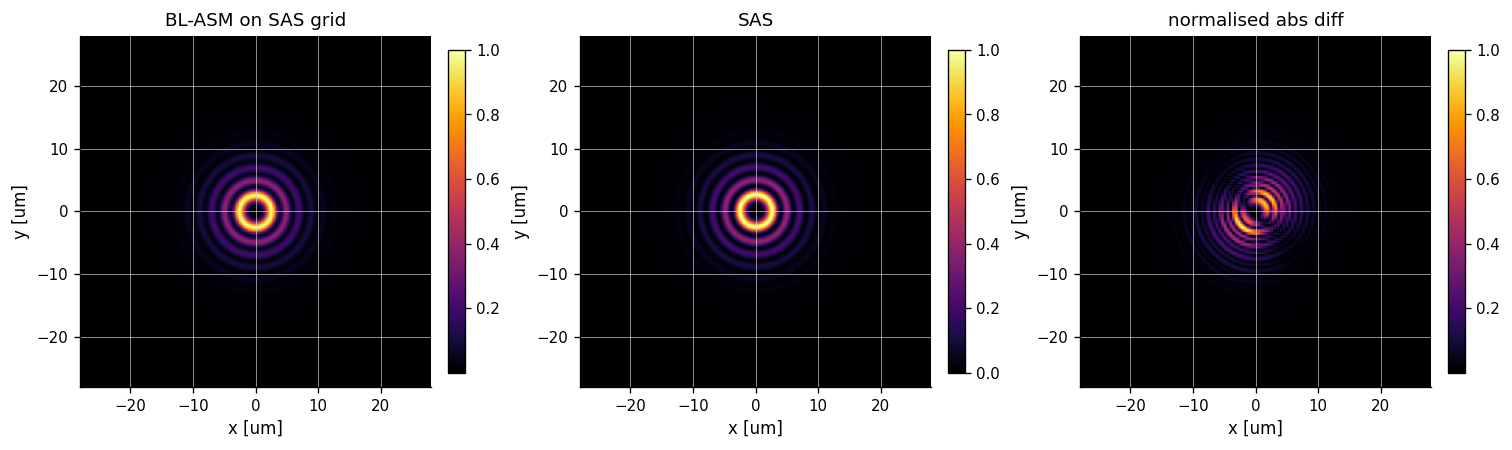

outputs\figures\publication_study\sas_validation_montage.png


In [6]:
I_bl, I_sas, g_sas, meta = examples["conical_axicon_input"]
diff = np.abs(normalise(I_sas) - normalise(I_bl))
extent = [g_sas["x"][0] / bt.um, g_sas["x"][-1] / bt.um, g_sas["x"][0] / bt.um, g_sas["x"][-1] / bt.um]
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
for a, img, title, cmap in zip(ax, [I_bl, I_sas, diff], ["BL-ASM on SAS grid", "SAS", "normalised abs diff"], [vbb_style.INTENSITY_CMAP, vbb_style.INTENSITY_CMAP, vbb_style.INTENSITY_CMAP]):
    im = a.imshow(normalise(img), origin="lower", extent=extent, cmap=cmap)
    a.set_title(title)
    a.set_xlabel("x [um]")
    a.set_ylabel("y [um]")
    fig.colorbar(im, ax=a, fraction=0.046)
montage_path = PUB_OUT["figures"] / "sas_validation_montage.png"
fig.savefig(montage_path, dpi=220, bbox_inches="tight")
plt.show()
print(montage_path.relative_to(PUB_ROOT))


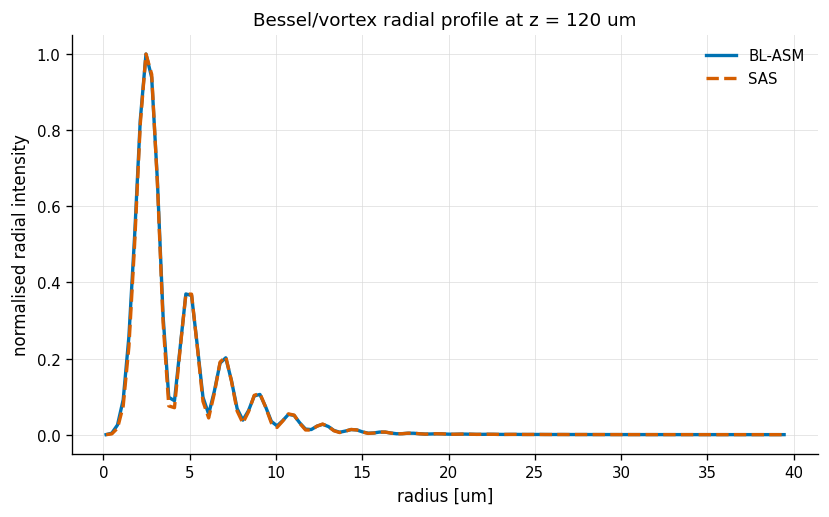

outputs\figures\publication_study\sas_validation_radial_profiles.png


In [7]:
r_bl, p_bl = bt.radial_profile(I_bl, g_sas, bins=120)
r_sas, p_sas = bt.radial_profile(I_sas, g_sas, bins=120)
fig, ax = plt.subplots(figsize=(6.8, 4.2), constrained_layout=True)
ax.plot(r_bl / bt.um, normalise(p_bl), label="BL-ASM", lw=2.0)
ax.plot(r_sas / bt.um, normalise(p_sas), label="SAS", lw=2.0, ls="--")
ax.set_xlabel("radius [um]")
ax.set_ylabel("normalised radial intensity")
ax.set_title("Bessel/vortex radial profile at z = 120 um")
ax.legend(frameon=False)
radial_path = PUB_OUT["figures"] / "sas_validation_radial_profiles.png"
fig.savefig(radial_path, dpi=220, bbox_inches="tight")
plt.show()
print(radial_path.relative_to(PUB_ROOT))


In [8]:
# PHASE7: propagation power QA
# Check propagation power drift for all cases found in notebook global scope.
# pass <= 5%, marginal <= 20%, fail > 20%.
# Fast preset is diagnostic/debug only. Publication preset improves drift, but
# does not make every case publication-ready; fail rows stay visible and should
# be treated as numerical diagnostics or rerun with finer grid/sampling/model setup.
import pandas as pd  # noqa: F811 (safe re-import)
_found_qa = False
for _name in [
    "summary",
    "df",
    "shortlist_df",
    "summary_df",
    "comparison_table",
    "preset_comparison",
    "oat",
    "tradeoff",
    "ell_family",
    "device_realism",
    "interface_depth",
]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame) and "propagation_power_label" in _df.columns:
        _qa_cols = ["preset", "case_id", "propagation_power_drift_fraction", "propagation_power_label"]
        _qa = _df[[c for c in _qa_cols if c in _df.columns]].copy()
        if "preset" not in _qa.columns:
            _qa["preset"] = globals().get("PRESET", "unknown")
        _summary = (
            _qa.groupby("preset", dropna=False)["propagation_power_label"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=["pass", "marginal", "fail"], fill_value=0)
            .reset_index()
        )
        print(f"Power QA counts by preset for '{_name}':")
        print(_summary.to_string(index=False))
        _pass = int((_qa["propagation_power_label"] == "pass").sum())
        _marginal = int((_qa["propagation_power_label"] == "marginal").sum())
        _fail = int((_qa["propagation_power_label"] == "fail").sum())
        print(f"Power QA for '{_name}': {_pass} pass, {_marginal} marginal, {_fail} fail")
        if _fail > 0:
            print("WARNING: FAIL cases (>20% drift) are NOT suitable for publication figures.")
        if _marginal > 0:
            print("NOTE: MARGINAL cases (5-20% drift) — review before publication.")
        _found_qa = True
        break
if not _found_qa:
    print("NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.")
    print("      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.")


NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.
      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.


In [9]:
# PHASE7: canonical zone vs strict region
# These are TWO DIFFERENT metrics. Never plot or report them interchangeably.
#
#   canonical_zone_um       = axial peak FWHM (single observable, broader)
#   strict_bessel_region_um = triple-intersection fabrication region (narrower)
#
# Use strict_bessel_region_um for fabrication planning and heatmaps.
# Use canonical_zone_um for optical diagnostic comparisons.
import pandas as pd  # noqa: F811
_zone_found = False
for _name in ["summary", "df", "shortlist_df", "summary_df", "oat", "tradeoff"]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame):
        _c, _s = "canonical_zone_um", "strict_bessel_region_um"
        if _c in _df.columns and _s in _df.columns:
            _id = "case_id" if "case_id" in _df.columns else _df.columns[0]
            _z = _df[[_id, _c, _s]].copy()
            _z["zone_margin_um"] = _z[_c] - _z[_s]
            _z["strict_fraction"] = (_z[_s] / _z[_c].replace(0, float("nan"))).round(3)
            print(f"Zone/region comparison for '{_name}' ({len(_z)} rows):")
            print(_z.to_string(index=False))
            print()
            print("  canonical_zone_um       = axial_peak_fwhm  (from bessel_zone_metrics)")
            print("  strict_bessel_region_um = strict_intersection_peak_power_radius (narrower)")
            _zone_found = True
            break
if not _zone_found:
    print("NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.")
    print("      Re-run after the cell that builds 'summary' or 'shortlist_df'.")


NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.
      Re-run after the cell that builds 'summary' or 'shortlist_df'.
